In [28]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import warnings
warnings.filterwarnings("ignore")

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    classification_report, confusion_matrix, accuracy_score,
    f1_score, roc_auc_score, ConfusionMatrixDisplay
)

In [29]:

print("STEP 1: Loading and filtering data")

df = pd.read_csv("DownloadAll.csv")
print(f"Raw shape: {df.shape}")

# Focus on nests (most consistent count type across sites/years)
df = df[df["count_type"] == "nests"].copy()
# Drop rows with missing penguin count
df = df.dropna(subset=["penguin_count"])
print(f"After filtering to 'nests' and dropping nulls: {df.shape}")

STEP 1: Loading and filtering data
Raw shape: (5407, 15)
After filtering to 'nests' and dropping nulls: (3961, 15)


In [30]:

print("STEP 2: Engineering trend label per colony")


def compute_trend(group):
    """
    Fit a linear regression of penguin_count ~ year for each colony.
    Label:
      'Growing'  if slope > +5% of mean count per year
      'Declining' if slope < -5% of mean count per year
      'Stable'   otherwise
    """
    if len(group) < 3:
        return None
    years = group["year"].values
    counts = group["penguin_count"].values
    if years.max() == years.min():
        return None
    slope = np.polyfit(years, counts, 1)[0]
    mean_count = counts.mean()
    if mean_count == 0:
        return None
    pct_change = slope / mean_count
    if pct_change > 0.05:
        return "Growing"
    elif pct_change < -0.05:
        return "Declining"
    else:
        return "Stable"

# Group by site + species to get one trend label per colony
colony_trends = (
    df.groupby(["site_id", "common_name"])
    .apply(compute_trend)
    .reset_index()
)
colony_trends.columns = ["site_id", "common_name", "trend"]
colony_trends = colony_trends.dropna(subset=["trend"])
print(f"Colonies with trend label: {len(colony_trends)}")
print(colony_trends["trend"].value_counts())

STEP 2: Engineering trend label per colony
Colonies with trend label: 253
trend
Stable       196
Declining     33
Growing       24
Name: count, dtype: int64


In [31]:

print("STEP 3: Building feature set")


# Aggregate static features per colony
site_features = df.groupby(["site_id", "common_name"]).agg(
    latitude=("latitude_epsg_4326", "first"),
    longitude=("longitude_epsg_4326", "first"),
    cammlr_region=("cammlr_region", "first"),
    first_year=("year", "min"),
    last_year=("year", "max"),
    mean_count=("penguin_count", "mean"),
    max_count=("penguin_count", "max"),
    num_surveys=("penguin_count", "count"),
).reset_index()

# Add temporal span as a feature
site_features["year_span"] = site_features["last_year"] - site_features["first_year"]

# Merge with trend labels
model_df = site_features.merge(colony_trends, on=["site_id", "common_name"])
print(f"Model dataset shape: {model_df.shape}")
print("\nBEFORE transformation (sample):")
print(model_df[["site_id", "common_name", "cammlr_region", "latitude", "longitude", "trend"]].head())



print("STEP 4: Encoding categorical features")


le_species = LabelEncoder()
le_region = LabelEncoder()
le_target = LabelEncoder()

model_df["species_enc"] = le_species.fit_transform(model_df["common_name"])
model_df["region_enc"] = le_region.fit_transform(model_df["cammlr_region"].astype(str))
model_df["trend_enc"] = le_target.fit_transform(model_df["trend"])

print("\nAFTER transformation (sample):")
print(model_df[["common_name", "species_enc", "cammlr_region", "region_enc", "trend", "trend_enc"]].head())
print(f"\nClass mapping: {dict(zip(le_target.classes_, le_target.transform(le_target.classes_)))}")

FEATURES = [
    "latitude", "longitude", "species_enc", "region_enc",
    "year_span", "mean_count", "max_count", "num_surveys"
]
TARGET = "trend_enc"

X = model_df[FEATURES]
y = model_df[TARGET]

STEP 3: Building feature set
Model dataset shape: (253, 12)

BEFORE transformation (sample):
  site_id        common_name cammlr_region  latitude  longitude   trend
0    ACUN     adelie penguin          48.2   -60.761    -44.637  Stable
1    ADAR     adelie penguin          88.1   -71.306    170.200  Stable
2    AITC  chinstrap penguin          48.1   -62.407    -59.752  Stable
3    AITC     gentoo penguin          48.1   -62.407    -59.752  Stable
4    ALCO  chinstrap penguin          48.1   -64.240    -61.127  Stable
STEP 4: Encoding categorical features

AFTER transformation (sample):
         common_name  species_enc cammlr_region  region_enc   trend  trend_enc
0     adelie penguin            0          48.2           1  Stable          2
1     adelie penguin            0          88.1           4  Stable          2
2  chinstrap penguin            1          48.1           0  Stable          2
3     gentoo penguin            3          48.1           0  Stable          2
4  chinstr


Train size: 189  |  Test size: 64
STEP 5: Hyperparameter tuning via GridSearchCV
Best parameters: {'class_weight': 'balanced', 'max_depth': None, 'min_samples_split': 2, 'n_estimators': 200}
Best CV F1 (weighted): 0.7606
STEP 6: Model Evaluation
Accuracy:           0.8125
F1 Score (weighted):0.7789
ROC-AUC (OvR):      0.7453

Classification Report:
              precision    recall  f1-score   support

   Declining       0.60      0.38      0.46         8
     Growing       1.00      0.17      0.29         6
      Stable       0.83      0.96      0.89        50

    accuracy                           0.81        64
   macro avg       0.81      0.50      0.55        64
weighted avg       0.82      0.81      0.78        64



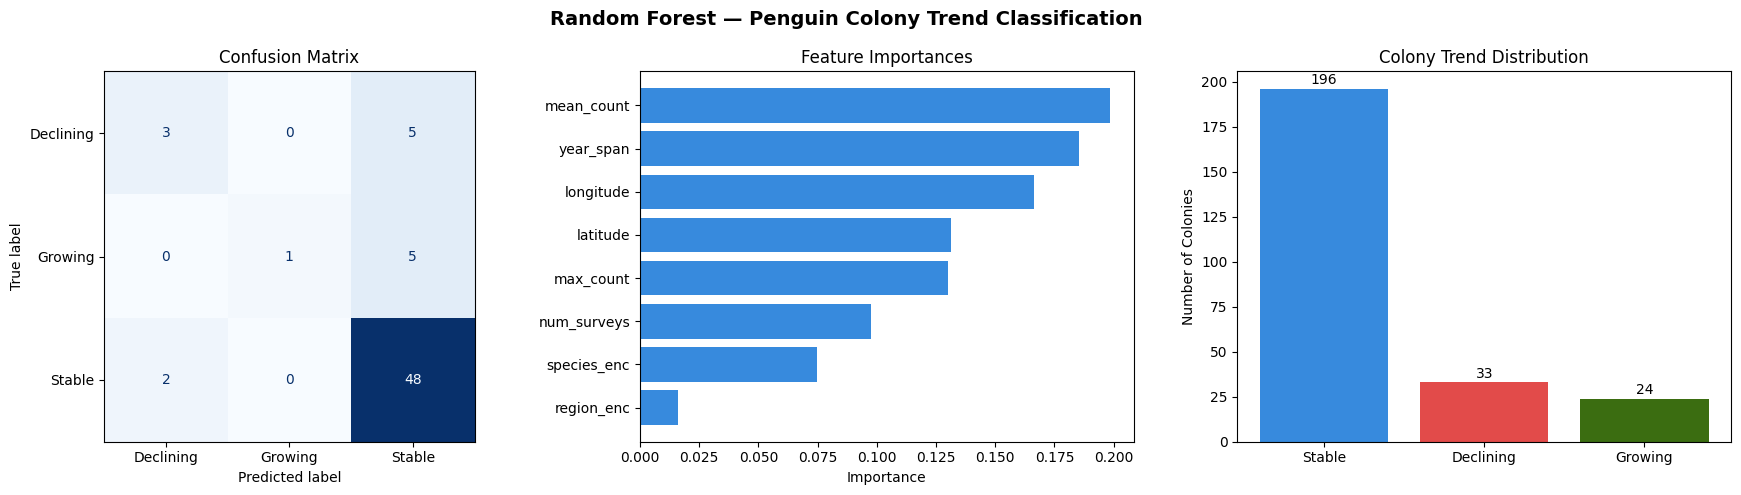


Saved: classification_results.png


In [32]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)
print(f"\nTrain size: {X_train.shape[0]}  |  Test size: {X_test.shape[0]}")

print("STEP 5: Hyperparameter tuning via GridSearchCV")


param_grid = {
    "n_estimators": [100, 200],
    "max_depth": [None, 10, 20],
    "min_samples_split": [2, 5],
    "class_weight": ["balanced"]
}

rf = RandomForestClassifier(random_state=42)
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

grid_search = GridSearchCV(
    rf, param_grid, cv=cv, scoring="f1_weighted", n_jobs=-1, verbose=0
)
grid_search.fit(X_train, y_train)

print(f"Best parameters: {grid_search.best_params_}")
print(f"Best CV F1 (weighted): {grid_search.best_score_:.4f}")

best_rf = grid_search.best_estimator_

print("STEP 6: Model Evaluation")


y_pred = best_rf.predict(X_test)
y_prob = best_rf.predict_proba(X_test)

acc = accuracy_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred, average="weighted")
try:
    roc = roc_auc_score(y_test, y_prob, multi_class="ovr", average="weighted")
except Exception:
    roc = None

print(f"Accuracy:           {acc:.4f}")
print(f"F1 Score (weighted):{f1:.4f}")
if roc:
    print(f"ROC-AUC (OvR):      {roc:.4f}")

print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=le_target.classes_))


fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle("Random Forest — Penguin Colony Trend Classification", fontsize=14, fontweight="bold")

# (a) Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=le_target.classes_)
disp.plot(ax=axes[0], colorbar=False, cmap="Blues")
axes[0].set_title("Confusion Matrix")

# (b) Feature Importance
importances = best_rf.feature_importances_
feat_df = pd.DataFrame({"feature": FEATURES, "importance": importances})
feat_df = feat_df.sort_values("importance", ascending=True)
axes[1].barh(feat_df["feature"], feat_df["importance"], color="#378ADD")
axes[1].set_title("Feature Importances")
axes[1].set_xlabel("Importance")

# (c) Class Distribution
colors = {"Growing": "#3B6D11", "Stable": "#378ADD", "Declining": "#E24B4A"}
value_counts = model_df["trend"].value_counts()
bars = axes[2].bar(value_counts.index, value_counts.values,
                   color=[colors[c] for c in value_counts.index])
axes[2].set_title("Colony Trend Distribution")
axes[2].set_ylabel("Number of Colonies")
for bar, val in zip(bars, value_counts.values):
    axes[2].text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 1,
                 str(val), ha="center", va="bottom", fontsize=10)

plt.tight_layout()
plt.savefig("classification_results.png", dpi=150, bbox_inches="tight")
plt.show()
print("\nSaved: classification_results.png")
